# Exploratory data analysis #

Instructions:

Run every cell of this code.
Answer any questions in the code by adding a new markdown/code cell.
DO NOT JUST EDIT THE EXISTING CELL WHICH CONTAINS THE QUESTION. Adding a new cell makes grading easier.
After you are done, submit the notebook including all the outputs and answers to Canvas as an .html file.

Exploratory data analysis is the act of visualizing and transforming
data to explore it in a systematic manner.
The process is an iterative cycle in which one
1. Generates questions about their data.
2. Searches for answers by visualizing, transforming, and
modeling their data.
3. Uses what they’ve learned to refine their questions and/or
generate novel questions.
Data cleaning/tidying is also an important component of exploratory
data analysis.

First, let's read the dataset from a csv file using read_csv function from pandas package.

In [18]:
import pandas as pd

df = pd.read_csv('heart_attack_prediction_dataset.csv')
# dataset was obtained here https://www.kaggle.com/datasets/m1relly/heart-attack-prediction?resource=download 
df

,Patient ID,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [19]:
df.dtypes # let's check the data types of all the variables

Patient ID                          object
Age                                  int64
Gender                              object
Cholesterol                          int64
Blood Pressure                      object
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                object
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                             object
Continent  

In [20]:
# here we specify which datatype we want some of the variables to be
df = pd.read_csv('heart_attack_prediction_dataset.csv',dtype={'Patient ID':'string','Blood Pressure':'string','Country':'category',
                                                              'Continent':'category','Hemisphere':'category'})
df.dtypes # we can check the datatypes again to see the changes

Patient ID                         string[python]
Age                                         int64
Gender                                     object
Cholesterol                                 int64
Blood Pressure                     string[python]
Heart Rate                                  int64
Diabetes                                    int64
Family History                              int64
Smoking                                     int64
Obesity                                     int64
Alcohol Consumption                         int64
Exercise Hours Per Week                   float64
Diet                                       object
Previous Heart Problems                     int64
Medication Use                              int64
Stress Level                                int64
Sedentary Hours Per Day                   float64
Income                                      int64
BMI                                       float64
Triglycerides                               int64


**1. Categorical features (variables)** can take on a small set of possible
values. Some of the real-world examples are gender (male, female, non-binary, etc.), marital status (single, married, divorced),
blood type (A, B, AB, O).
They are also divided into **nominal variables** - no particular order (e.g., gender, country, blood type) and
 **ordinal variables** - meaningful order (e.g., education level, satisfaction rating, income bracket, etc.).
 
**2. Continuous features (variables)** can take on an infinite set of ordered values (weight, distance, age, etc.).

In [ ]:
df[df.isna().any(axis=1)]  # check for NaN ('Not a Number') values 

,Patient ID,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk


**What do we do with rows where values are missing?**
1. Remove these rows!
2. We can even remove columns containing NaN values (not happening most of the time!)
3. We can fill the missing values with mean/median
4. Fill them with 0 (PLEASE DO NOT DO THIS!)
5. Leave them as they are...

In [21]:
df.shape

(8763, 26)

In [22]:
df = df.dropna(axis=0) # removes rows containing NaN values
df.shape

(8761, 26)

In [23]:
list(df) # to print out all the column names

['Patient ID',
 'Age',
 'Gender',
 'Cholesterol',
 'Blood Pressure',
 'Heart Rate',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Exercise Hours Per Week',
 'Diet',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Sedentary Hours Per Day',
 'Income',
 'BMI',
 'Triglycerides',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'Country',
 'Continent',
 'Hemisphere',
 'Heart Attack Risk']

In [24]:
df.head()

,Patient ID,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [25]:
df.tail()

,Patient ID,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0
8762,ZWN9666,25,Female,356,138/67,75,1,1,0,0,...,9.005234,247338,32.914151,180,7,4,United Kingdom,Europe,Northern Hemisphere,1


In [ ]:
#this creates a new column called 'Sedentary Hours Per Week' by multiplying the values in the 'Sedentary Hours Per Day' column by 7
df['Sedentary Hours Per Week']=df['Sedentary Hours Per Day']* 7

df['Sedentary Hours Per Week']

0       46.305010
1       34.744212
2       66.243981
3       53.542866
4       10.603746
          ...    
8758    75.644612
8759    26.831266
8760    16.626496
8761     0.203730
8762    63.036641
Name: Sedentary Hours Per Week, Length: 8761, dtype: float64

In [30]:
df.columns

Index(['Patient ID', 'Age', 'Gender', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk',
       'Sedentary Hours Per Week'],
      dtype='object')

In [33]:
df['Age'].describe() # to get the descriptive statistics of a single variable

count    8761.000000
mean       53.707796
std        21.248707
min        18.000000
25%        35.000000
50%        54.000000
75%        72.000000
max        90.000000
Name: Age, dtype: float64

In [42]:
df['age_categories'] = pd.cut(x = df['Age'], bins = [0,20,40,60], labels = ['young', 'adult', 'older'])
df

,Patient ID,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Sedentary Hours Per Week,age_categories
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0,46.305010,NaN
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0,34.744212,adult
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,28.176571,587,4,4,France,Europe,Northern Hemisphere,0,66.243981,adult
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0,53.542866,NaN
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0,10.603746,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0,75.644612,older
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0,26.831266,adult
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1,16.626496,older
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0,0.203730,adult


In [ ]:
df['age_categories'].value_counts()

age_categories
older      3570
adult      2450
elderly    2360
young       381
baby          0
vampire       0
Name: count, dtype: int64

__Question 1. What do you think will happen with patients who are older than 60?__

Your answer

 ## It will either throw an error or a NaN

Well, let's see!

In [43]:
old = df.loc[df['Age']  > 60]

old

,Patient ID,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Sedentary Hours Per Week,age_categories
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0,46.305010,NaN
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0,53.542866,NaN
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0,10.603746,NaN
6,WYV0966,90,Male,358,102/73,84,0,0,1,0,...,28.885811,284,4,10,Canada,North America,Northern Hemisphere,1,4.391492,NaN
7,XXM0972,84,Male,220,131/68,107,0,0,1,1,...,22.221862,370,6,7,Japan,Asia,Northern Hemisphere,1,73.806462,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8748,GQZ5013,81,Male,137,143/64,61,1,0,1,1,...,35.074391,191,3,10,Spain,Europe,Southern Hemisphere,0,47.368638,NaN
8751,SVO4635,75,Male,176,102/89,78,0,0,1,1,...,23.793280,748,5,8,Spain,Europe,Southern Hemisphere,1,46.444918,NaN
8752,UBM5982,65,Male,150,152/99,106,1,0,1,0,...,22.710546,83,1,5,Argentina,South America,Southern Hemisphere,0,51.277493,NaN
8753,NVC8704,82,Male,311,126/108,87,0,1,1,1,...,27.694240,515,1,5,Australia,Australia,Southern Hemisphere,1,58.820840,NaN


In [44]:
#Let's create another column for 'Age category' based on the column Age
df['Age_category'] = pd.cut(x = df['Age'], bins = [0,30,60,100], labels = ['young', 'adult', 'older'])

In [45]:
df['Age_category'].describe() # however, it does not tell us the count for other categories!

count      8761
unique        3
top       adult
freq       3594
Name: Age_category, dtype: object

In [ ]:
df['Age_category'].value_counts() # but, this does!

#Note to Self: This sorts by frequency in descending order, not by the order of the categories.


Age_category
adult    3594
older    3553
young    1614
Name: count, dtype: int64

In [ ]:
# Another amazing thing we can do...
df.groupby(['Age_category'],observed=False).size()
#Note to selt: the difference between observed True and False is that the former only counts the categories that are present in the data, while the latter counts all the categories, even if they are not present in the data ie: 0 counts.

#Note to Self: This sorts by index order, which is the order of the categories. This is, imo, a better way to see the distribution of the categories.

Age_category
young    1614
adult    3594
older    3553
dtype: int64

In [59]:
df.groupby(['Age_category','Gender'],observed=False).size().reset_index()

,Age_category,Gender,0
0,young,Female,517
1,young,Male,1097
2,adult,Female,1071
3,adult,Male,2523
4,older,Female,1062
5,older,Male,2491


In a pandas DataFrame, the index refers to the labels or identifiers that are associated with each row. It's essentially the row identifier for each observation or record in the DataFrame.
When you create a DataFrame without specifying an index, pandas automatically assigns a default integer index starting from 0. This means the rows are labeled as 0, 1, 2, 3, ..., n-1 (n is the number of rows)

A MultiIndex (or hierarchical index) is a more complex index that allows multiple levels of indexing (after the groupby function above)
In order to go back to 0,1,2,3... indexing, we use reset_index() function.

In [53]:
df.groupby(['Age_category','Gender'],observed=False).size().reset_index(name='Count') 


,Age_category,Gender,Count
0,young,Female,517
1,young,Male,1097
2,adult,Female,1071
3,adult,Male,2523
4,older,Female,1062
5,older,Male,2491


f you performed an aggregation, such as .size(), .sum(), .mean(), etc., the resulting series will have the aggregation result, but the name of that column is usually not meaningful or left as None.
By using reset_index(name='your_column_name'), you name the new aggregated column (the one that holds the result of the aggregation, such as the count or sum).

In [54]:
df.groupby(['Age_category','Gender'],observed=False)['Cholesterol'].mean()


Age_category  Gender
young         Female    251.572534
              Male      263.491340
adult         Female    259.350140
              Male      261.394372
older         Female    262.171375
              Male      257.743878
Name: Cholesterol, dtype: float64

In [58]:
df.groupby(['Age_category','Gender'],observed=False)['Cholesterol'].mean().reset_index(name ='Average Cholesterol Level')


,Age_category,Gender,Average Cholesterol Level
0,young,Female,251.572534
1,young,Male,263.491340
2,adult,Female,259.350140
3,adult,Male,261.394372
4,older,Female,262.171375
5,older,Male,257.743878


In [62]:
df2 = df[['Age_category','Gender','Cholesterol','Heart Rate','BMI','Sleep Hours Per Day']] # the way to get only specific columns from a dataframe
df2.groupby(['Age_category','Gender'],observed=False).mean()
# using .mean() function will calculate the average value per age category and sex. It will do it for all the variables in the dataframe
# however, it would throw an error if we would do it with df (as some columns are not numeric)

Cholesterol  Heart Rate        BMI  Sleep Hours Per Day
Age_category Gender                                                         
young        Female   251.572534   75.719536  28.893272             7.071567
             Male     263.491340   74.531449  28.963523             7.009116
adult        Female   259.350140   75.496732  29.023215             6.991597
             Male     261.394372   75.334919  28.787672             7.057471
older        Female   262.171375   75.030132  28.828776             7.075330
             Male     257.743878   74.557607  28.933964             6.978322

In [63]:
df.groupby(['Country'],observed=False).size()

Country
Argentina         471
Australia         449
Brazil            462
Canada            440
China             435
Colombia          429
France            446
Germany           477
India             412
Italy             431
Japan             433
New Zealand       434
Nigeria           448
South Africa      425
South Korea       409
Spain             430
Thailand          428
United Kingdom    457
United States     420
Vietnam           425
dtype: int64

In [64]:
df.groupby(['Country','Obesity'],observed=False).size()

Country         Obesity
Argentina       0          236
                1          235
Australia       0          215
                1          234
Brazil          0          228
                1          234
Canada          0          213
                1          227
China           0          213
                1          222
Colombia        0          217
                1          212
France          0          202
                1          244
Germany         0          244
                1          233
India           0          209
                1          203
Italy           0          217
                1          214
Japan           0          220
                1          213
New Zealand     0          225
                1          209
Nigeria         0          220
                1          228
South Africa    0          212
                1          213
South Korea     0          205
                1          204
Spain           0          231
               

In [69]:
# findings binary variables
# Check unique values in each column
unique_values = df.nunique()

# Filter columns that have exactly 2 unique values
binary_columns = unique_values[unique_values == 2].index
print("Binary columns:" + str(binary_columns))

Binary columns:Index(['Gender', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Previous Heart Problems', 'Medication Use',
       'Hemisphere', 'Heart Attack Risk'],
      dtype='object')


In [71]:
binary_columns = unique_values[unique_values == 2]
print("Binary columns:" + str(binary_columns))

Binary columns:Gender                     2
Diabetes                   2
Family History             2
Smoking                    2
Obesity                    2
Alcohol Consumption        2
Previous Heart Problems    2
Medication Use             2
Hemisphere                 2
Heart Attack Risk          2
dtype: int64


In [96]:
df2 = df[['Diabetes', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Previous Heart Problems', 'Heart Attack Risk','Country']]

# by using mean() with binary variables, we can actually get the percentage of observations that belong to the positive class!
# Note that when selecting columns from df, I used only numeric columns
df2.groupby(['Country'],observed=False).mean()


,Diabetes,Smoking,Obesity,Alcohol Consumption,Previous Heart Problems,Heart Attack Risk
Country,,,,,,
Argentina,0.660297,0.889597,0.498938,0.600849,0.498938,0.369427
Australia,0.648107,0.877506,0.521158,0.579065,0.503341,0.374165
Brazil,0.614719,0.896104,0.506494,0.564935,0.491342,0.352814
Canada,0.661364,0.872727,0.515909,0.593182,0.525000,0.359091
China,0.625287,0.896552,0.510345,0.560920,0.494253,0.356322
Colombia,0.643357,0.885781,0.494172,0.638695,0.522145,0.377622
France,0.665919,0.892377,0.547085,0.605381,0.446188,0.352018
Germany,0.645702,0.899371,0.488470,0.597484,0.492662,0.360587
India,0.643204,0.910194,0.492718,0.618932,0.441748,0.313107


In [ ]:
df2.groupby(['Country'], observed=False).mean().rename(columns=lambda x: f"{x} by Mean")

,Diabetes by Mean,Smoking by Mean,Obesity by Mean,Alcohol Consumption by Mean,Previous Heart Problems by Mean,Heart Attack Risk by Mean
Country,,,,,,
Argentina,0.660297,0.889597,0.498938,0.600849,0.498938,0.369427
Australia,0.648107,0.877506,0.521158,0.579065,0.503341,0.374165
Brazil,0.614719,0.896104,0.506494,0.564935,0.491342,0.352814
Canada,0.661364,0.872727,0.515909,0.593182,0.525000,0.359091
China,0.625287,0.896552,0.510345,0.560920,0.494253,0.356322
Colombia,0.643357,0.885781,0.494172,0.638695,0.522145,0.377622
France,0.665919,0.892377,0.547085,0.605381,0.446188,0.352018
Germany,0.645702,0.899371,0.488470,0.597484,0.492662,0.360587
India,0.643204,0.910194,0.492718,0.618932,0.441748,0.313107


In [98]:
df3 = df2.groupby(['Country'],observed=False).mean()

**Data Distributions** show the shape of your data, such as whether it’s symmetrical, skewed, or has peaks. This helps you understand whether the data follows any specific patterns or if there are unusual behaviors.
**Normal distribution**: If the data follows a bell-shaped curve (normal distribution), many statistical tests and assumptions can be applied, which we will cover later in the course.

**Skewed distribution**: If the data is skewed (a long tail on one side), it suggests the need for transformation or special handling when modeling.
<img src="Distribution.png" alt="Normal distribution vs Skewed" width="400" height="100">

**Bimodal or multimodal distributions**: If the data has multiple peaks, it could indicate the presence of distinct groups or different processes influencing the data.
<img src="Bimodal_histogram.jpeg" alt="Bimodal" width="400" height="100">

**To check the distributions, we plot histograms. A histogram is a type of chart or plot that visualizes the distribution of a set of continuous (or discrete) numerical data by showing the frequency (or count) of values that fall within specific ranges, called bins.**

We need to evaluate data distributions before conducting any statistical analysis, as appropriate statistical tests are determined by the data distributions.



<Axes: xlabel='Sedentary Hours Per Day', ylabel='Count'>

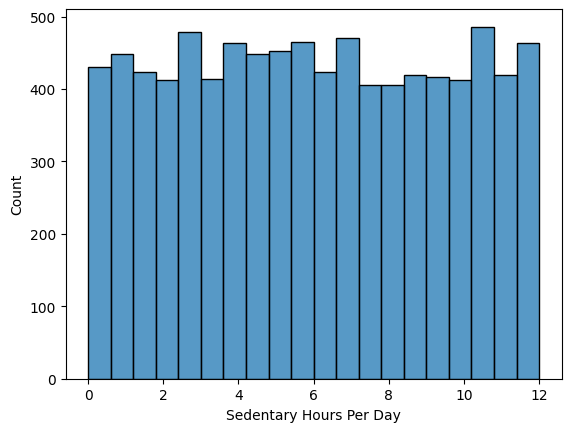

In [ ]:
import seaborn as sns

sns.histplot(data = df, x="Sedentary Hours Per Day",bins=40)
#note to self, bins in this case, is the number of bars in the histogram. 

<Axes: xlabel='Cholesterol', ylabel='Count'>

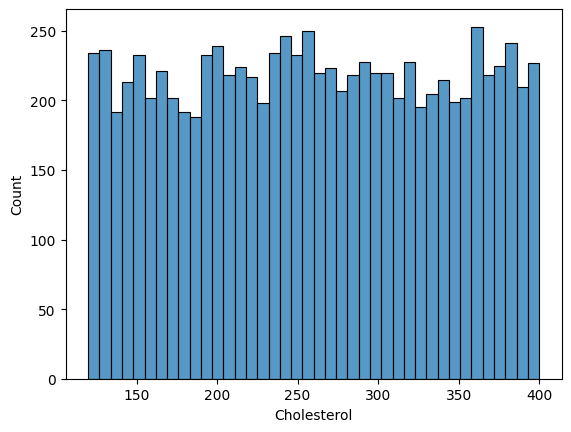

In [105]:
sns.histplot(data = df, x="Cholesterol",bins=40)

**What kind of distribution is this?**

Your answer

## Using the examples above, i would say it's a multimodal, but it could also be considered fairly uniform depending on relativity. For example, it is more multimodal than the graph above it, but more uniform than the graph for age i created below:

<Axes: xlabel='Age', ylabel='Count'>

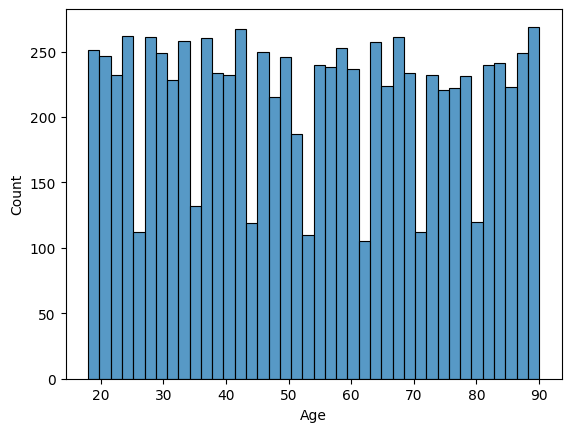

In [107]:
sns.histplot(data = df, x="Age",bins=40)

<Axes: xlabel='Cholesterol'>

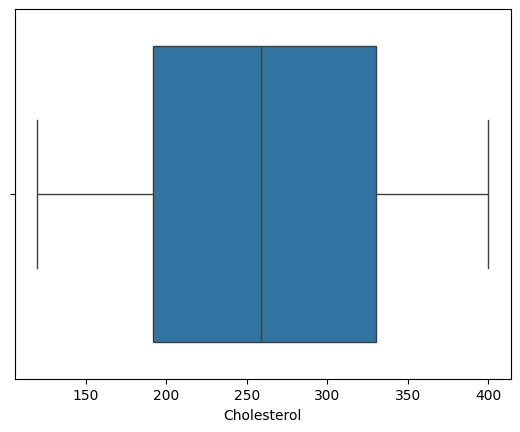

In [106]:
sns.boxplot(data = df, x="Cholesterol")

**Based on the boxplot above, what is Q1, Q3, and the median?**

Your answer

In [109]:
df['Cholesterol'].describe()

count    8761.000000
mean      259.883689
std        80.858224
min       120.000000
25%       192.000000
50%       259.000000
75%       330.000000
max       400.000000
Name: Cholesterol, dtype: float64

## Q1: 192
## Q3: 330
## Median: 259


Boxplot:
The central box represents the middle 50% of the data.
The top and bottom edges of the box are called quartiles.
The lower quartile (Q1) is the 25th percentile (the value below which 25% of the data fall).
The upper quartile (Q3) is the 75th percentile (the value below which 75% of the data fall).
The line inside the box represents the median (the middle value of the dataset).
Whiskers- min and max

We see the same information from describe()

In [ ]:
df.describe()

**Mean**: The sum of all data points divided by the number of points.
Why it matters: It gives a quick idea of the "central" value of the data. However, it can be sensitive to outliers (extremely high or low values), making it less reliable for skewed distributions.

**Median**: The middle value when data is sorted. If there's an even number of data points, it’s the average of the two middle values.
Why it matters: The median is robust to outliers and skewed data, so it often provides a better "central" value when the data is not symmetrically distributed.

**Variance**: A measure of how far each data point is from the mean, calculated by averaging the squared differences from the mean.
Why it matters: Variance quantifies the spread or dispersion of the data. However, because it’s in squared units, it can be hard to interpret in the context of the data.

**Standard deviation**: The square root of variance, showing how much the data deviates from the mean, in the original units of the data.
Why it matters: Standard deviation is a more intuitive measure of spread, making it easier to understand the variability of the data in the context of the units you’re measuring (e.g., dollars, meters).

**Quartiles**: Data is divided into four equal parts. The 1st (Q1), 2nd (Q2/Median), and 3rd (Q3) quartiles mark the 25th, 50th, and 75th percentiles, respectively.
Why it matters: Quartiles help understand the distribution of data, showing the range of values in the lower, middle, and upper parts. The Interquartile Range (IQR) (Q3 - Q1) is especially useful for detecting outliers.

**What do we do with outliers?** It is good practice to repeat analyses with and without outliers.
If the outliers have minimal effect on results, and one cannot figure
out why they are in the dataset, then it is reasonable to replace them
with missing values (NA).
However, if the outliers have substantial effect on the results, then
they should not be dropped without justification.
The analyst will need to figure out what caused these unusual values
(e.g., a data entry error), and disclose that they were removed in
whatever write-up or report is made based on the data

In [ ]:
gender = df.groupby(['Gender'],observed=False).size().reset_index(name='count')
gender
#note to self: reset index resets the index from 0, i think itll be useful for when we want to do further analysis on the grouped data, as it allows us to access the group labels as columns rather than as an index.

,Gender,count
0,Female,2650
1,Male,6111


<Axes: xlabel='Gender', ylabel='count'>

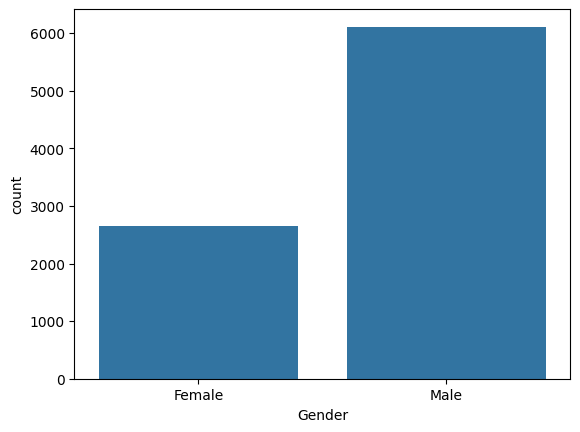

In [114]:
sns.barplot(data = gender, x="Gender",y='count')

In [115]:
gender = df.groupby(['Gender', 'Age_category'],observed=False)['Stress Level'].mean().reset_index(name='avg_stress')
gender

,Gender,Age_category,avg_stress
0,Female,young,5.454545
1,Female,adult,5.546218
2,Female,older,5.638418
3,Male,young,5.425706
4,Male,adult,5.367023
5,Male,older,5.492172


<Axes: xlabel='Age_category', ylabel='avg_stress'>

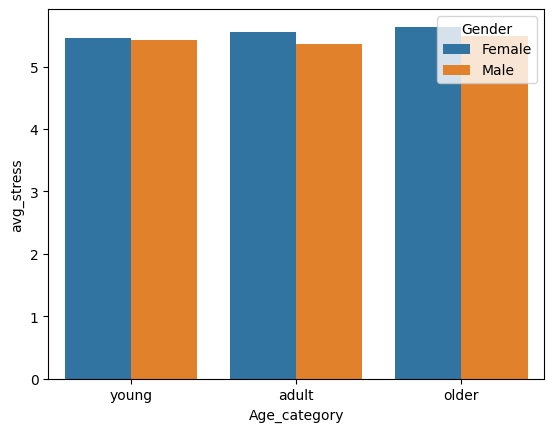

In [116]:
sns.barplot(data = gender, x="Age_category",y='avg_stress',hue='Gender')

In [117]:
age = df.groupby(['Age'],observed=False).size().reset_index(name = 'count')
age

,Age,count
0,18,123
1,19,128
2,20,130
3,21,117
4,22,124
...,...,...
68,86,105
69,87,126
70,88,123
71,89,117


<Axes: xlabel='Age', ylabel='count'>

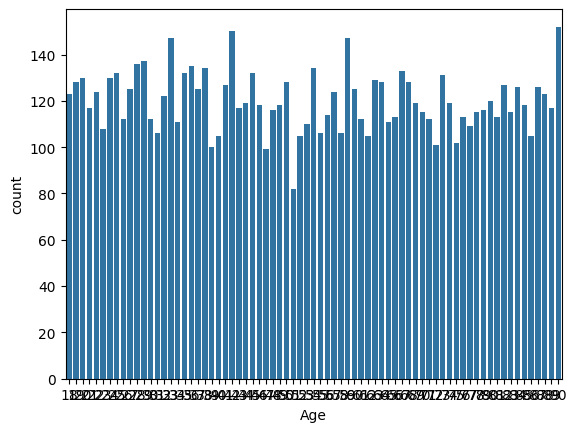

In [118]:
sns.barplot(data = age, x="Age",y='count')

Question: What is the problem here?

Your answer

## The X axis is too hard to read because the labels bleed into eachother

Question: Fix it! Create a new plot that you think will look more readable

In [ ]:
# Answer

In [161]:
sorted_df = df['Age'].sort_values()
#here I am checking to see what the youngest ages are, and then the oldest, so I can decide on the bin range
youngest = sorted_df.head()
oldest = sorted_df.tail()

print("Youngest ages:")
print(youngest)

print("Oldest ages:")
print(oldest)


Youngest ages:
3486    18
4756    18
8704    18
8147    18
6816    18
Name: Age, dtype: int64
Oldest ages:
2985    90
2967    90
2951    90
8129    90
5007    90
Name: Age, dtype: int64


<Axes: xlabel='Age', ylabel='Count'>

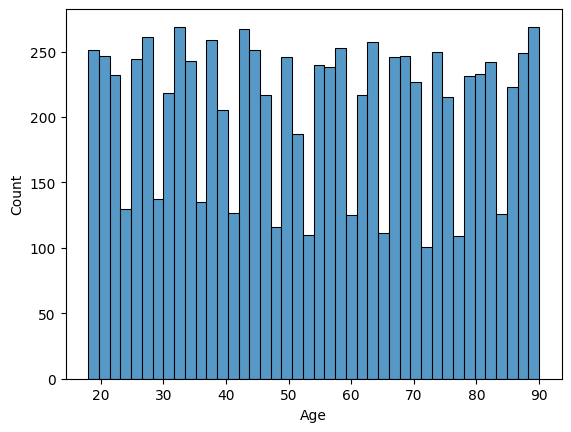

In [175]:
sns.histplot(data=df, x="Age", bins=42, binrange=(18, 90))

## Additional - Me Messing Around

<Axes: xlabel='Age Category', ylabel='count'>

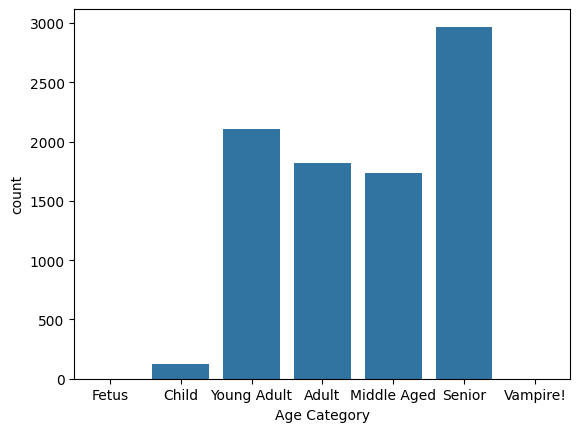

In [173]:
df = df.drop(columns=["Age Category", "Age_category"], errors="ignore")
df['Age_category'] = pd.cut(df['Age'], bins=[-1, 0, 18, 35, 50, 65, 100, 1000], labels=['Fetus', 'Child', 'Young Adult', 'Adult', 'Middle Aged', 'Senior', 'Vampire!'])
df = df.rename(columns={'Age_category': 'Age Category'})
sns.countplot(data=df, x="Age Category")
#this doesnt count because it doesnt show the ages as easily, this is just more me messing around with what I learnt :)